这个文档开始讨论随时间变化的时候，IRIS光谱沿着狭缝的变化

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 定义高斯函数
def gaussian(x, a, x0, sigma,noise):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))+noise
def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2, c):
        return (a1 * np.exp(-(x - x1)**2 / (2 * sigma1**2)) +
                a2 * np.exp(-(x - x2)**2 / (2 * sigma2**2)) + c)
def gaussiannn(i,rsm,mu_initial):
    import numpy as np
    from scipy.optimize import curve_fit
    import matplotlib.pyplot as plt
    #截取出参考的波长区间
    wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
    wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
    #大多数是70：110
    x=wave_x[70:110]
    y=wave_y[70:110]
    #剔除掉一些特别大的点
    mask=y>4*np.mean(y)
    if np.any(mask):
         good_idx=np.where(~mask)[0]
         y_interp=np.interp(np.arange(len(y)),good_idx,y[good_idx])
         y[mask]=y_interp[mask]
    # 设定初始参数
    #mu_initial = 1402.3  # 参考给定均值
    a_initial = max(y)  # 初始振幅设为 y 的最大值
    sigma_initial = 0.05  # 初始标准差
    noise_initial=0
    initial_guess = [a_initial, mu_initial, sigma_initial,noise_initial]
    # 进行高斯拟合
    popt, pcov = curve_fit(gaussian, x, y, p0=initial_guess)
    # 获取拟合参数
    a_fit, x0_fit, sigma_fit,noise_fit = popt
    sigma_fit=abs(sigma_fit)
    # 打印拟合结果
    print(f"拟合参数:")
    print(f"峰值振幅 a = {a_fit}")
    print(f"均值 μ = {x0_fit}")
    print(f"标准差 σ = {sigma_fit}")
    v1=(x0_fit-1402.77)/1402.77*299792.458
    print('多普勒速度为',v1)
    v2=sigma_fit/1402.77*299792.458
    print('速度展宽为',v2)
    # 生成拟合曲线
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = gaussian(x_fit, *popt)
    # 绘制图像
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="point", color="red")  # 画原始数据点
    plt.plot(x_fit, y_fit, label="Gaussian", color="blue")  # 画拟合曲线
    plt.axvline(x=1402.77, color='black', linestyle='--', linewidth=1.5, label="x=1402.77")  # 画参考竖线
    plt.title("Single Gaussian Fitting")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    return v1,v2

In [3]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')

In [4]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_all.npz')
doppler_vel_all = data['doppler_vel_all']
sigma_vel_all = data['sigma_vel_all']

In [ ]:
# data = np.load('doppler_sigma_velocity.npz')
# doppler_vel799 = data['doppler_vel']
# sigma_vel799 = data['sigma_vel']

# #我创建一个总的多普勒速度和速度展宽的矩阵，从797、799、。。。一直到819一共12个时刻的数据，每个时刻取110个点
# #那么创建的矩阵就都是12*110
# doppler_vel_all=np.zeros((12,110))
# sigma_vel_all=np.zeros((12,110))
# doppler_vel_all[1,:]=doppler_vel799[110:]
# sigma_vel_all[1,:]=sigma_vel799[110:]

In [ ]:
k=409
rsm=fits.open(file_list[k])
doppler_vel=np.zeros((110))
sigma_vel=np.zeros((110))
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
path=r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_figure\\'+str(2*k+1)
if not os.path.exists(path):
    os.mkdir(path)
for i in range(110):
    wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
    x=wave_x[70:110]
    y=wave_y[70:110]
    mean_y=np.mean(y)
    #剔除掉一些特别大的点
    mask=y>5*np.mean(y)
    if np.any(mask):
         good_idx=np.where(~mask)[0]
         y_interp=np.interp(np.arange(len(y)),good_idx,y[good_idx])
         y[mask]=y_interp[mask]    
    
    #初始参数
    mu_ref=1402.77
    # if i>=93:
    #     mu_initial=1402.3
    # else:
    #     mu_initial=1402.77
    mu_initial=1402.77
    a_initial=np.mean(y)
    noise_initial=0
    sigma_initial=0.05
    initial_guess=[a_initial,mu_initial,sigma_initial,noise_initial]
    popt,pcov=curve_fit(gaussian,x,y,p0=initial_guess)
    #获取参数
    a_fit,mu_fit,sigma_fit,noise_fit=popt
    sigma_fit=abs(sigma_fit)
    #计算多普勒速度
    doppler_vel[i]=(mu_fit-mu_ref)/mu_ref*299792.458
    sigma_vel[i]=sigma_fit/mu_ref*299792.458
    y_fit=gaussian(x,*popt)
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="point", color="red")  # 画原始数据点
    plt.plot(x, y_fit, label="Gaussian", color="blue")  # 画拟合曲线
    plt.axvline(x=1402.77, color='black', linestyle='--', linewidth=1.5, label="x=1402.77")  # 画参考竖线
    plt.title("Single Gaussian Fitting")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.savefig(path+'/'+str(i+110)+'.png')
    plt.close()
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)  # 创建2行1列的子图，sharex=True表示共享x轴
xrange=np.arange(110,220)
fig.subplots_adjust(hspace=0.05)  # 调整子图之间的间距
ax1.minorticks_on()
# 绘制多普勒速度
color = 'tab:red'
ax1.set_ylabel('Doppler velocity km/s', color=color)
ax1.plot(xrange,doppler_vel, color=color)
ax1.tick_params(axis='y', labelcolor=color)
# 绘制sigma的绝对值
color = 'tab:blue'
ax2.set_ylabel('Velocity dispersion km/s', color=color)
ax2.plot(xrange,sigma_vel, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.minorticks_on()
fig.tight_layout()  # 调整子图参数，使之填充整个图像区域

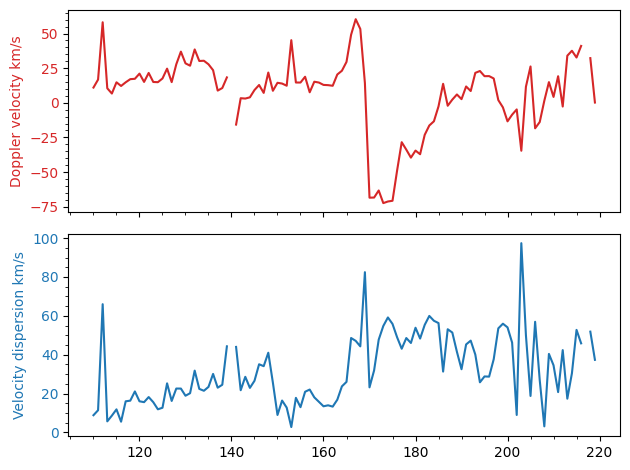

In [191]:
doppler_vel=doppler_vel_all[0,:]
sigma_vel=sigma_vel_all[0,:]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)  # 创建2行1列的子图，sharex=True表示共享x轴
xrange=np.arange(110,220)
fig.subplots_adjust(hspace=0.05)  # 调整子图之间的间距
ax1.minorticks_on()
# 绘制多普勒速度
color = 'tab:red'
ax1.set_ylabel('Doppler velocity km/s', color=color)
ax1.plot(xrange,doppler_vel, color=color)
ax1.tick_params(axis='y', labelcolor=color)
# 绘制sigma的绝对值
color = 'tab:blue'
ax2.set_ylabel('Velocity dispersion km/s', color=color)
ax2.plot(xrange,sigma_vel, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.minorticks_on()
fig.tight_layout()  # 调整子图参数，使之填充整个图像区域

拟合参数:
峰值振幅 a = 34.84087355970881
均值 μ = 1402.4311927816013
标准差 σ = 0.25634959574706895
多普勒速度为 -72.40805605471446
速度展宽为 54.785656534086236


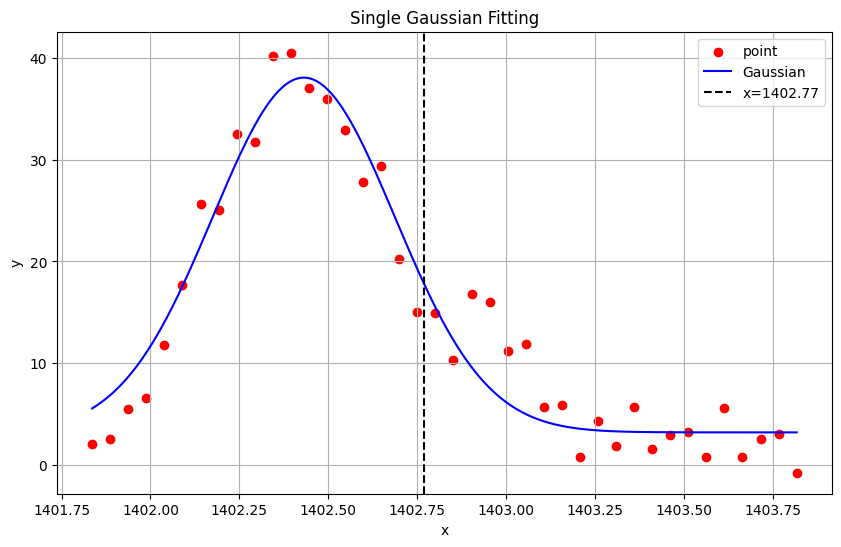

In [193]:
k=398
rsm=fits.open(file_list[k])
i=63
v1,v2=gaussiannn(i,rsm,1402.3)

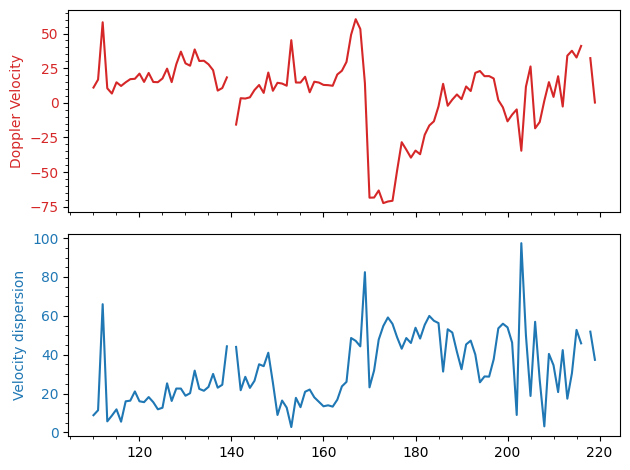

In [194]:
keyword=0
if keyword==0:
    doppler_vel[i],sigma_vel[i]=v1,v2
else:
    doppler_vel[i],sigma_vel[i]=np.nan,np.nan
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)  # 创建2行1列的子图，sharex=True表示共享x轴
fig.subplots_adjust(hspace=0.05)  # 调整子图之间的间距
ax1.minorticks_on()
# 绘制多普勒速度
color = 'tab:red'
xrange=np.arange(110,220)
ax1.set_ylabel('Doppler Velocity', color=color)
ax1.plot(xrange,doppler_vel, color=color)
ax1.tick_params(axis='y', labelcolor=color)
# 绘制sigma的绝对值
color = 'tab:blue'
ax2.set_ylabel('Velocity dispersion', color=color)
ax2.plot(xrange,sigma_vel, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.minorticks_on()
fig.tight_layout()  # 调整子图参数，使之填充整个图像区域

In [171]:
doppler_vel_all[k-398,:]=doppler_vel
sigma_vel_all[k-398,:]=sigma_vel
np.savez(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\\doppler_sigma_vel_all.npz',
         doppler_vel_all=doppler_vel_all,sigma_vel_all=sigma_vel_all)

In [82]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\\doppler_sigma_vel_all.npz')
doppler_vel_all=data['doppler_vel_all']
sigma_vel_all=data['sigma_vel_all']

In [5]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']

In [10]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%d T%H:%M:%S')
    time_sequence.append(time_str)

In [172]:
cnt=0
for i in range(797,820,2):
    fig,down_ax=plt.subplots(figsize=(6,5))
    fig_data=all_sji_image[i][0][330:,:]
    down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
            extent=[0,422*0.166,0,330*0.166])
    down_ax.set_xlabel('X [arcsec]')
    down_ax.set_ylabel('Y [arcsec]')
    down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'
    right_ax = down_ax.twinx()
    right_ax.set_ylim(110, 220)
    #创建第二根x轴
    up_ax=down_ax.twiny()
    #转化单位到角秒
    y_vals=np.linspace(0,330*0.166,110)
    up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel_all[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-210,190)
    up_ax.set_xlabel('Velocity [km/s]')
    up_ax.set_title(time_sequence[i])
    up_ax.legend(loc='lower left')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='blue',linestyle='--')
    plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\fig_with_vel\\'+str(i)+'.png',dpi=300)
    plt.close()
    cnt=cnt+1

对809时刻进行双高斯拟合

In [12]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 使用黑体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

rsm=fits.open(file_list[404])
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
x=wave_x[70:110]
start_x,end_x=187,219
velocity=np.zeros((end_x-start_x,4))
for i in range(start_x,end_x):
    y=rsm[4].data[4,65+i*3:68+i*3,:].mean(axis=0)[70:110]
    # 定义双高斯函数
    def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2, c):
        return (a1 * np.exp(-(x - x1)**2 / (2 * sigma1**2)) +
                a2 * np.exp(-(x - x2)**2 / (2 * sigma2**2)) + c)

    # 设定初始参数 (根据数据大致估计)
    a1_initial = max(y) - min(y)  # 第一个高斯的振幅
    x1_initial =1402.7  # 第一个高斯中心
    sigma1_initial = 0.1          # 经验设定标准差

    a2_initial = a1_initial * 0.8  # 第二个高斯振幅 (稍小一点)
    x2_initial = 1402.2  # 第二个高斯中心 (稍微偏移)
    sigma2_initial = 0.1           # 经验设定标准差

    c_initial = np.min(y)          # 背景噪声设为最小 y 值

    # 组合初始参数
    initial_guess = [a1_initial, x1_initial, sigma1_initial, 
                    a2_initial, x2_initial, sigma2_initial, c_initial]

    # 进行拟合
    popt, pcov = curve_fit(double_gaussian, x, y, p0=initial_guess, maxfev=5000)

    # 获取拟合参数
    a1_fit, x1_fit, sigma1_fit, a2_fit, x2_fit, sigma2_fit, c_fit = popt
    velocity[i-start_x,0]=(x1_fit-1402.77)/1402.77*299792.458
    velocity[i-start_x,1]=sigma1_fit/1402.77*299792.458
    velocity[i-start_x,2]=(x2_fit-1402.77)/1402.77*299792.458
    velocity[i-start_x,3]=sigma2_fit/1402.77*299792.458
    # 打印拟合结果
    print(f"拟合参数:")
    print(f"峰值 1 振幅 a1 = {a1_fit}, 中心 x1 = {x1_fit}, 标准差 sigma1 = {sigma1_fit}")
    print(f"峰值 2 振幅 a2 = {a2_fit}, 中心 x2 = {x2_fit}, 标准差 sigma2 = {sigma2_fit}")
    print(f"常数噪声 c = {c_fit}")

    # 生成拟合曲线
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = double_gaussian(x_fit, *popt)

    # 绘制图像
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="data", color="red")  # 画原始数据点
    plt.plot(x_fit, y_fit, label="Double Gaussian Fitting", color="blue")  # 画拟合曲线
    plt.axvline(x=1402.77,color='black',linestyle='--')
    # plt.axvline(x=x1_fit, color='green', linestyle='--', label=f"峰 1: x={x1_fit:.3f}")
    # plt.axvline(x=x2_fit, color='purple', linestyle='--', label=f"峰 2: x={x2_fit:.3f}")
    plt.title("Double Gaussian Fitting")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    #plt.show()
    plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_figure\double_809\\'+str(i)+'.png')   
    plt.close()
print(velocity)

拟合参数:
峰值 1 振幅 a1 = 84.94253445316379, 中心 x1 = 1402.8097419565963, 标准差 sigma1 = 0.18881298078168154
峰值 2 振幅 a2 = 188.76458769267447, 中心 x2 = 1402.4494485104115, 标准差 sigma2 = 0.1397090108283668
常数噪声 c = 1.5294550925804409
拟合参数:
峰值 1 振幅 a1 = 77.44971392635459, 中心 x1 = 1402.6405512498104, 标准差 sigma1 = 0.2912561651947038
峰值 2 振幅 a2 = 129.71654647355447, 中心 x2 = 1402.405008144744, 标准差 sigma2 = 0.13790480243418826
常数噪声 c = 1.1277525902344694
拟合参数:
峰值 1 振幅 a1 = 109.23046921355548, 中心 x1 = 1402.5149399199595, 标准差 sigma1 = 0.281456035746398
峰值 2 振幅 a2 = 147.46408519056487, 中心 x2 = 1402.3240451751885, 标准差 sigma2 = 0.11913910431394559
常数噪声 c = 0.5661064452359966
拟合参数:
峰值 1 振幅 a1 = 126.15788205740843, 中心 x1 = 1402.5079791056912, 标准差 sigma1 = 0.24617787502833682
峰值 2 振幅 a2 = 120.3900640004329, 中心 x2 = 1402.301337844676, 标准差 sigma2 = 0.13696886469023078
常数噪声 c = 0.9373534139144976
拟合参数:
峰值 1 振幅 a1 = 101.50093862469689, 中心 x1 = 1402.5382324769478, 标准差 sigma1 = 0.2539655529680752
峰值 2 振幅 a2 = 90.252922

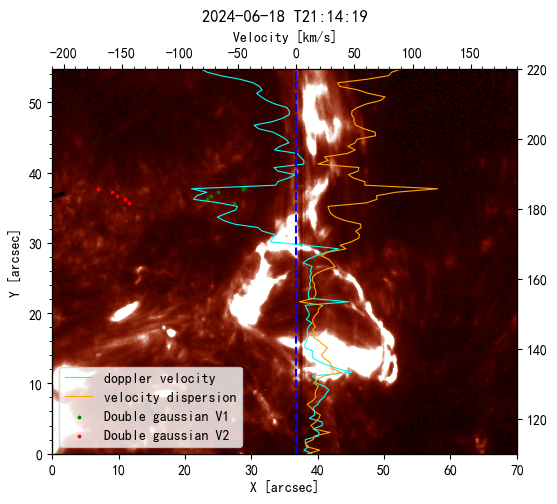

In [11]:
i=813
cnt=8
fig,down_ax=plt.subplots(figsize=(6,5))
fig_data=all_sji_image[i][0][330:,:]
down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
        extent=[0,422*0.166,0,330*0.166])
down_ax.set_xlabel('X [arcsec]')
down_ax.set_ylabel('Y [arcsec]')
down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'
right_ax = down_ax.twinx()
right_ax.set_ylim(110, 220)
#创建第二根x轴
up_ax=down_ax.twiny()
#转化单位到角秒
y_vals=np.linspace(0,330*0.166,110)
up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
up_ax.plot(sigma_vel_all[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
up_ax.set_xlim(-210,190)

#画上双高斯拟合的散点图
double_y=y_vals[start_x-110:end_x-110]
up_ax.scatter(velocity[:,0],double_y,label='Double gaussian V1',s=3,color='green')
up_ax.scatter(velocity[:,2],double_y,label='Double gaussian V2',s=3,color='red')

up_ax.set_xlabel('Velocity [km/s]')
up_ax.set_title(time_sequence[i])
up_ax.legend()
up_ax.minorticks_on()
up_ax.axvline(0,color='blue',linestyle='--')


对799时刻双高斯拟合

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
kk=409
rsm=fits.open(file_list[kk])
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
x=wave_x[70:110]
start_x,end_x=169,174
velocity=np.zeros((end_x-start_x,4))
for i in range(start_x,end_x):
    y=rsm[4].data[4,65+i*3:68+i*3,:].mean(axis=0)[70:110]
    # 定义双高斯函数
    def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2, c):
        return (a1 * np.exp(-(x - x1)**2 / (2 * sigma1**2)) +
                a2 * np.exp(-(x - x2)**2 / (2 * sigma2**2)) + c)

    # 设定初始参数 (根据数据大致估计)
    a1_initial = max(y) - min(y)  # 第一个高斯的振幅
    x1_initial =1402.77  # 第一个高斯中心
    sigma1_initial = 0.1          # 经验设定标准差

    a2_initial = a1_initial * 0.8  # 第二个高斯振幅 (稍小一点)
    x2_initial = 1402.3  # 第二个高斯中心 (稍微偏移)
    sigma2_initial = 0.1           # 经验设定标准差

    c_initial = np.min(y)          # 背景噪声设为最小 y 值

    # 组合初始参数
    initial_guess = [a1_initial, x1_initial, sigma1_initial, 
                    a2_initial, x2_initial, sigma2_initial, c_initial]

    # 进行拟合
    popt, pcov = curve_fit(double_gaussian, x, y, p0=initial_guess, maxfev=5000)

    # 获取拟合参数
    a1_fit, x1_fit, sigma1_fit, a2_fit, x2_fit, sigma2_fit, c_fit = popt
    velocity[i-start_x,0]=(x1_fit-1402.77)/1402.77*299792.458
    velocity[i-start_x,1]=sigma1_fit/1402.77*299792.458
    velocity[i-start_x,2]=(x2_fit-1402.77)/1402.77*299792.458
    velocity[i-start_x,3]=sigma2_fit/1402.77*299792.458
    # 打印拟合结果
    print(f"拟合参数:")
    print(f"峰值 1 振幅 a1 = {a1_fit}, 中心 x1 = {x1_fit}, 标准差 sigma1 = {sigma1_fit}")
    print(f"峰值 2 振幅 a2 = {a2_fit}, 中心 x2 = {x2_fit}, 标准差 sigma2 = {sigma2_fit}")
    print(f"常数噪声 c = {c_fit}")

    # 生成拟合曲线
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = double_gaussian(x_fit, *popt)

    # 绘制图像
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="data", color="red")  # 画原始数据点
    plt.plot(x_fit, y_fit, label="Double Gaussian Fitting", color="blue")  # 画拟合曲线
    plt.axvline(x=1402.77,color='black',linestyle='--')
    # plt.axvline(x=x1_fit, color='green', linestyle='--', label=f"峰 1: x={x1_fit:.3f}")
    # plt.axvline(x=x2_fit, color='purple', linestyle='--', label=f"峰 2: x={x2_fit:.3f}")
    plt.title("Double Gaussian Fitting")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    #plt.show()
    plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_figure\double_'+str(kk*2+1)+'\\'+str(i)+'.png')   
    plt.close()
print(velocity)

拟合参数:
峰值 1 振幅 a1 = 313.0920572020661, 中心 x1 = 1402.9530793881438, 标准差 sigma1 = 0.1231485799002535
峰值 2 振幅 a2 = -23.185340163906506, 中心 x2 = 1402.0027020368284, 标准差 sigma2 = 0.15758807746436576
常数噪声 c = 19.34251381439823
拟合参数:
峰值 1 振幅 a1 = 230.75045073165748, 中心 x1 = 1402.9350773833812, 标准差 sigma1 = 0.12630696757060558
峰值 2 振幅 a2 = 75.86590148543182, 中心 x2 = 1402.549201227691, 标准差 sigma2 = 0.15082050674657213
常数噪声 c = 2.638424470431292
拟合参数:
峰值 1 振幅 a1 = 205.48292882546457, 中心 x1 = 1402.8719563487653, 标准差 sigma1 = 0.13726502632929177
峰值 2 振幅 a2 = 233.87481247716778, 中心 x2 = 1402.491264525036, 标准差 sigma2 = 0.12454352576645457
常数噪声 c = 3.437572675641321
拟合参数:
峰值 1 振幅 a1 = 83.39668214086792, 中心 x1 = 1402.8178791109951, 标准差 sigma1 = 0.14845443385561022
峰值 2 振幅 a2 = 259.12354318227756, 中心 x2 = 1402.4279360645012, 标准差 sigma2 = 0.12674962820266705
常数噪声 c = 4.153886149201864
拟合参数:
峰值 1 振幅 a1 = 38.463919305764485, 中心 x1 = 1402.8344153947003, 标准差 sigma1 = 0.16353710105774918
峰值 2 振幅 a2 = 158.8340

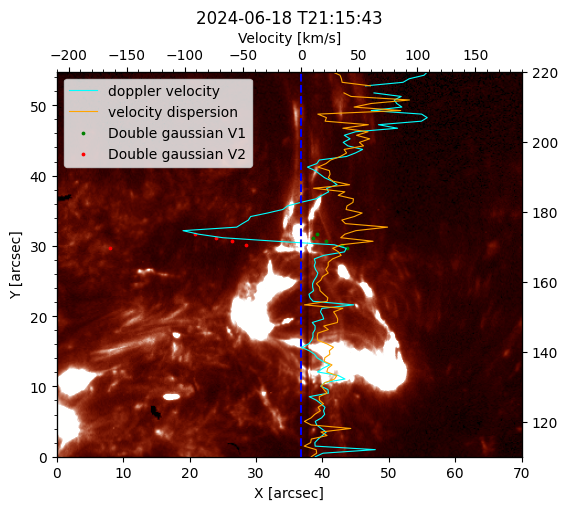

In [214]:
i=kk*2+1
cnt=kk-398
fig,down_ax=plt.subplots(figsize=(6,5))
fig_data=all_sji_image[i][0][330:,:]
down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
        extent=[0,422*0.166,0,330*0.166])
down_ax.set_xlabel('X [arcsec]')
down_ax.set_ylabel('Y [arcsec]')
down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'
right_ax = down_ax.twinx()
right_ax.set_ylim(110, 220)
#创建第二根x轴
up_ax=down_ax.twiny()
#转化单位到角秒
y_vals=np.linspace(0,330*0.166,110)
up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
up_ax.plot(sigma_vel_all[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
up_ax.set_xlim(-210,190)

#画上双高斯拟合的散点图
double_y=y_vals[start_x-110:end_x-110]
up_ax.scatter(velocity[:,0],double_y,label='Double gaussian V1',s=3,color='green')
up_ax.scatter(velocity[:,2],double_y,label='Double gaussian V2',s=3,color='red')

up_ax.set_xlabel('Velocity [km/s]')
up_ax.set_title(time_sequence[i])
up_ax.legend()
up_ax.minorticks_on()
up_ax.axvline(0,color='blue',linestyle='--')
